
# 01 — LPT basics: flat & spherical painting + power spectrum

Small demo that builds Gaussian initial conditions, runs first-order LPT, paints a flat and spherical map, and inspects 3D and angular power spectra.


In [1]:

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")


'cpu'

In [2]:

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

from fwd_model_tools import gaussian_initial_conditions
from fwd_model_tools.pm import lpt
from fwd_model_tools.power import angular_cl_flat, angular_cl_spherical


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


ERROR:2025-11-25 02:33:54,604:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_OPERATING_SYSTEM


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [3]:

# Simulation setup (keep tiny for a quick demo)
key = jax.random.PRNGKey(0)
mesh_size = (16, 16, 16)
box_size = (200.0, 200.0, 200.0)  # Mpc/h
nside = 16
flatsky_npix = (64, 64)

# Simple toy linear power spectrum
pk_fn = lambda k: 1.0 / (1.0 + (k / 0.1) ** 3)
cosmo = jc.Planck15()


In [4]:

# 1) Gaussian initial density field
initial_field = gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    pk_fn=pk_fn,
    cosmo=cosmo,
    nside=nside,
    flatsky_npix=flatsky_npix,
)
print(initial_field)


DensityField(array=Array(16, 16, 16), mesh_size=(16, 16, 16), box_size=(200.0, 200.0, 200.0), status=initial_field, scale_factors_shape=(1,))


In [5]:

# 2) First-order LPT displacements/momenta
scale_factor = 0.5
dx_field, p_field = lpt(cosmo, initial_field, a=scale_factor, order=1)
print(dx_field)


shape of initial force: (16, 16, 16, 3)
growth factor shape: (1,)


ParticleField(array=Array(16, 16, 16, 3), mesh_size=(16, 16, 16), box_size=(200.0, 200.0, 200.0), status=lpt1, scale_factors_shape=(1,))


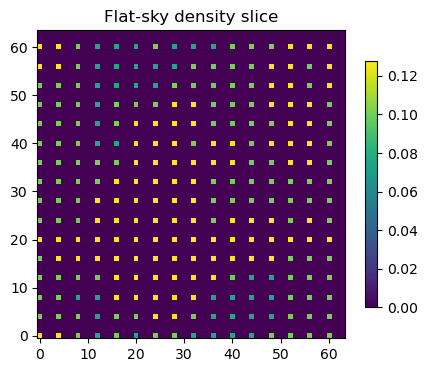

In [6]:

# 3) Flat-sky painting from LPT displacements
plane_center = box_size[2] / 2.0
flat_map = dx_field.paint_2d(center=plane_center, density_plane_width=box_size[2] / 4)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.asarray(flat_map.array), origin="lower")
ax.set_title("Flat-sky density slice")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()


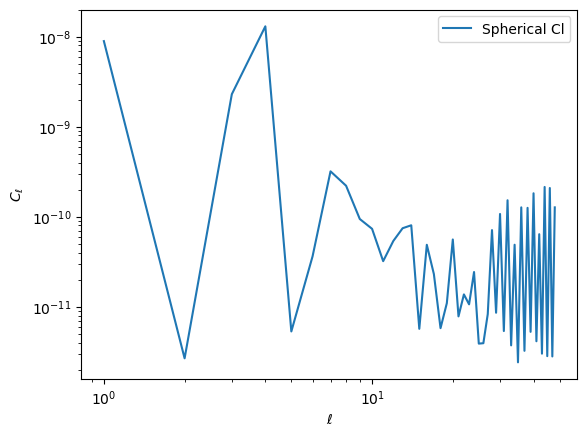

In [7]:

# 4) Spherical painting (single shell) and angular Cl
shell_center = box_size[2] / 2.0
sph_map = dx_field.paint_spherical(center=shell_center, density_plane_width=box_size[2] / 4)
ell_sph, cl_sph = angular_cl_spherical(sph_map.array, lmax=3 * nside)

plt.loglog(np.asarray(ell_sph[1:]), np.asarray(cl_sph[1:]), label="Spherical Cl")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.show()


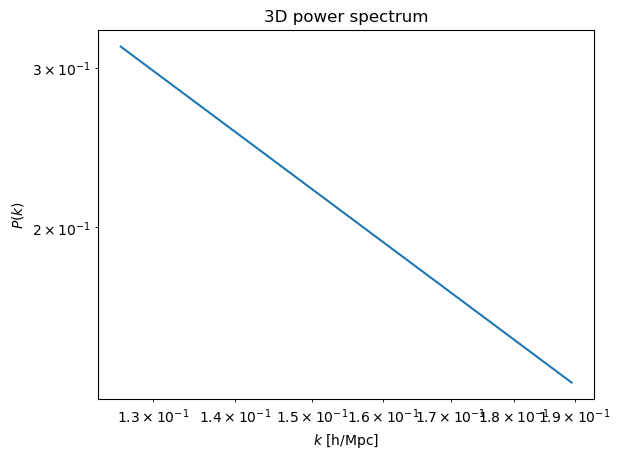

In [8]:

# 5) 3D power spectrum of the initial density
ps_3d = initial_field.power()
k = np.asarray(ps_3d.wavenumber)
pk = np.asarray(ps_3d.spectra)
plt.loglog(k, pk)
plt.xlabel(r"$k$ [h/Mpc]")
plt.ylabel(r"$P(k)$")
plt.title("3D power spectrum")
plt.show()


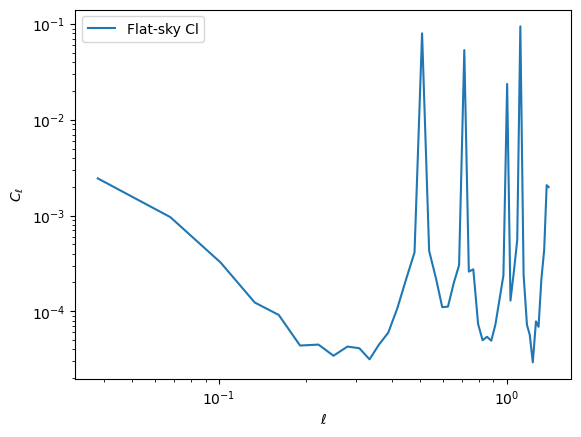

In [9]:

# 6) Flat-sky angular Cl of the painted slice
pixel_size = box_size[0] / flatsky_npix[0]
ell_flat, cl_flat = angular_cl_flat(flat_map.array, pixel_size=pixel_size)

plt.loglog(np.asarray(ell_flat[1:]), np.asarray(cl_flat[1:]), label="Flat-sky Cl")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.show()



**Notes**
- Mesh and map sizes are intentionally tiny so the notebook executes quickly.
- Power spectra use toy inputs; replace `pk_fn` or increase resolution for science runs.
